In [1]:
import tensorflow as tf

from tensorflow.keras import layers, models

import numpy as np



# --- CIFAR-10 로드 ---

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()



# 클래스 이름 정의

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',

               'dog', 'frog', 'horse', 'ship', 'truck']



# 사용할 클래스 선택

selected_classes = ['cat', 'dog', 'horse']

selected_idx = [class_names.index(c) for c in selected_classes]



# --- 해당 클래스만 필터링 ---

train_mask = np.isin(y_train, selected_idx).flatten()

test_mask = np.isin(y_test, selected_idx).flatten()



x_train, y_train = x_train[train_mask], y_train[train_mask]

x_test, y_test = x_test[test_mask], y_test[test_mask]



# 라벨을 0~2로 다시 매핑

label_map = {v: i for i, v in enumerate(selected_idx)}

y_train = np.array([label_map[int(y)] for y in y_train])

y_test = np.array([label_map[int(y)] for y in y_test])



# 정규화

x_train, x_test = x_train / 255.0, x_test / 255.0



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


/tmp/ipython-input-700971542.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_train = np.array([label_map[int(y)] for y in y_train])
/tmp/ipython-input-700971542.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_test = np.array([label_map[int(y)] for y in y_test])


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# 1️⃣ CIFAR-10 데이터 로드
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 클래스 이름 정의
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 사용할 클래스 선택
selected_classes = ['cat', 'dog', 'horse']
selected_idx = [class_names.index(c) for c in selected_classes]

# 2️⃣ 해당 클래스만 필터링
train_mask = np.isin(y_train, selected_idx).flatten()
test_mask = np.isin(y_test, selected_idx).flatten()

x_train, y_train = x_train[train_mask], y_train[train_mask]
x_test, y_test = x_test[test_mask], y_test[test_mask]

# 라벨을 0~2로 다시 매핑
label_map = {v: i for i, v in enumerate(selected_idx)}
y_train = np.array([label_map[int(y)] for y in y_train])
y_test = np.array([label_map[int(y)] for y in y_test])

# 3️⃣ 정규화
x_train = x_train / 255.0
x_test = x_test / 255.0

print("x_train shape:", x_train.shape)  # (약 15000, 32, 32, 3)
print("x_test shape:", x_test.shape)    # (약 3000, 32, 32, 3)
print("Classes:", selected_classes)

# 4️⃣ CNN 모델 구성
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3개 클래스
])

# 5️⃣ 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 6️⃣ 학습
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

# 7️⃣ 평가
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# 8️⃣ 예측 예시
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
predicted_classes = [selected_classes[i] for i in predicted_labels]
actual_classes = [selected_classes[i] for i in y_test[:5]]

print("\n예측 결과:", predicted_classes)
print("실제 결과:", actual_classes)
print("예측 확신도:", np.max(predictions, axis=1))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


/tmp/ipython-input-3211064705.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_train = np.array([label_map[int(y)] for y in y_train])
/tmp/ipython-input-3211064705.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_test = np.array([label_map[int(y)] for y in y_test])
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


x_train shape: (15000, 32, 32, 3)
x_test shape: (3000, 32, 32, 3)
Classes: ['cat', 'dog', 'horse']
Epoch 1/10
106/106 - 9s - 88ms/step - accuracy: 0.4955 - loss: 0.9778 - val_accuracy: 0.6087 - val_loss: 0.8431
Epoch 2/10
106/106 - 1s - 6ms/step - accuracy: 0.6187 - loss: 0.8028 - val_accuracy: 0.6527 - val_loss: 0.7695
Epoch 3/10
106/106 - 1s - 6ms/step - accuracy: 0.6611 - loss: 0.7300 - val_accuracy: 0.6873 - val_loss: 0.7029
Epoch 4/10
106/106 - 1s - 5ms/step - accuracy: 0.7016 - loss: 0.6682 - val_accuracy: 0.7147 - val_loss: 0.6579
Epoch 5/10
106/106 - 1s - 6ms/step - accuracy: 0.7190 - loss: 0.6324 - val_accuracy: 0.7200 - val_loss: 0.6431
Epoch 6/10
106/106 - 1s - 6ms/step - accuracy: 0.7412 - loss: 0.5945 - val_accuracy: 0.7260 - val_loss: 0.6481
Epoch 7/10
106/106 - 1s - 6ms/step - accuracy: 0.7548 - loss: 0.5669 - val_accuracy: 0.7347 - val_loss: 0.6096
Epoch 8/10
106/106 - 1s - 6ms/step - accuracy: 0.7735 - loss: 0.5311 - val_accuracy: 0.7307 - val_loss: 0.6325
Epoch 9/10
1

/tmp/ipython-input-3303157293.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_train = np.array([label_map[int(y)] for y in y_train])
/tmp/ipython-input-3303157293.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_test = np.array([label_map[int(y)] for y in y_test])


x_train shape: (15000, 32, 32, 3)
x_test shape: (3000, 32, 32, 3)
Classes: ['cat', 'dog', 'horse']
Epoch 1/10
106/106 - 7s - 68ms/step - accuracy: 0.5144 - loss: 0.9476 - val_accuracy: 0.6073 - val_loss: 0.8454
Epoch 2/10
106/106 - 1s - 7ms/step - accuracy: 0.6254 - loss: 0.7945 - val_accuracy: 0.6540 - val_loss: 0.7477
Epoch 3/10
106/106 - 1s - 6ms/step - accuracy: 0.6637 - loss: 0.7315 - val_accuracy: 0.6827 - val_loss: 0.7072
Epoch 4/10
106/106 - 1s - 6ms/step - accuracy: 0.6968 - loss: 0.6728 - val_accuracy: 0.7013 - val_loss: 0.6727
Epoch 5/10
106/106 - 1s - 6ms/step - accuracy: 0.7181 - loss: 0.6283 - val_accuracy: 0.7067 - val_loss: 0.6728
Epoch 6/10
106/106 - 1s - 6ms/step - accuracy: 0.7464 - loss: 0.5865 - val_accuracy: 0.7373 - val_loss: 0.6176
Epoch 7/10
106/106 - 1s - 6ms/step - accuracy: 0.7511 - loss: 0.5760 - val_accuracy: 0.7553 - val_loss: 0.5856
Epoch 8/10
106/106 - 1s - 6ms/step - accuracy: 0.7743 - loss: 0.5244 - val_accuracy: 0.7493 - val_loss: 0.5845
Epoch 9/10
1

/tmp/ipython-input-3303157293.py:90: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3303157293.py:90: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3303157293.py:90: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3303157293.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3303157293.py:90: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3303157293.py:90: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3303157293.py:90: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


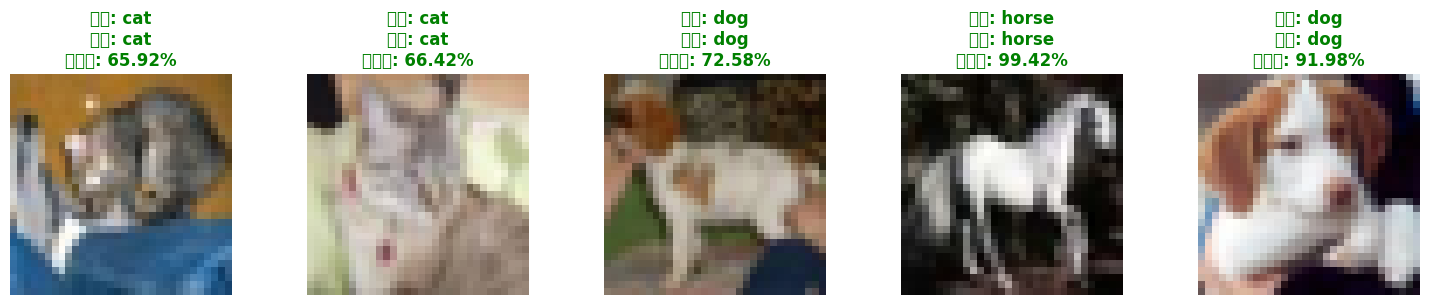


예측 결과: ['cat', 'cat', 'dog', 'horse', 'dog']
실제 결과: ['cat', 'cat', 'dog', 'horse', 'dog']
예측 확신도: ['65.92%', '66.42%', '72.58%', '99.42%', '91.98%']


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# 1️⃣ CIFAR-10 데이터 로드
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 클래스 이름 정의
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 사용할 클래스 선택
selected_classes = ['cat', 'dog', 'horse']
selected_idx = [class_names.index(c) for c in selected_classes]

# 2️⃣ 해당 클래스만 필터링
train_mask = np.isin(y_train, selected_idx).flatten()
test_mask = np.isin(y_test, selected_idx).flatten()

x_train, y_train = x_train[train_mask], y_train[train_mask]
x_test, y_test = x_test[test_mask], y_test[test_mask]

# 라벨을 0~2로 다시 매핑
label_map = {v: i for i, v in enumerate(selected_idx)}
y_train = np.array([label_map[int(y)] for y in y_train])
y_test = np.array([label_map[int(y)] for y in y_test])

# 3️⃣ 정규화
x_train = x_train / 255.0
x_test = x_test / 255.0

print("x_train shape:", x_train.shape)  # (약 15000, 32, 32, 3)
print("x_test shape:", x_test.shape)    # (약 3000, 32, 32, 3)
print("Classes:", selected_classes)

# 4️⃣ CNN 모델 구성
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3개 클래스
])

# 5️⃣ 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 6️⃣ 학습
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

# 7️⃣ 평가
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# 8️⃣ 예측 예시 (이미지 포함)
import matplotlib.pyplot as plt

predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
predicted_classes = [selected_classes[i] for i in predicted_labels]
actual_classes = [selected_classes[i] for i in y_test[:5]]
confidences = np.max(predictions, axis=1)

# 이미지 출력
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(x_test[i])

    # 맞은지 틀린지 판단
    is_correct = predicted_classes[i] == actual_classes[i]
    color = 'green' if is_correct else 'red'

    title = f"예측: {predicted_classes[i]}\n실제: {actual_classes[i]}\n확신도: {confidences[i]:.2%}"
    axes[i].set_title(title, color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\n예측 결과:", predicted_classes)
print("실제 결과:", actual_classes)
print("예측 확신도:", [f"{c:.2%}" for c in confidences])